In [1]:
from utils import (
    load_session_dumps,
    build_session_summary,
    preprocess_dumps,
    flag_outlier_dumps,
    vlsr_correction,
    build_overlap_grid,
    build_lsr_pairs,
    flag_outlier_pairs,
    combine_viable_pairs,
    assemble_W_R_arrays,
)
from plotters import (
    plot_survey_mollweide,
    plot_survey_mollweide_gridded,
)
from ugradiolab import plotting
from ugradiolab.plotting import SS_MICRO, SS_FINE

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# --- Hardware / signal-processing constants ---
SAMPLE_RATE_HZ = 3.2e6
NFFT = 1024
F1_MHZ = 1419.86
F2_MHZ = 1421.14
HPBW_DEG = 3.4
# NBLOCKS * NSAMPLES / fs (post-rewrite main pipeline)
INT_TIME_S = 1025 * 16384 / SAMPLE_RATE_HZ  # ~5.25 s

# --- RFI channel flagger (applied to both pols) ---
RFI_WINDOW = 15
RFI_SIGMA = 10.0
RFI_CHEB_DEGREE = 3
RFI_SAMPLE_FRAC = 0.7
RFI_EXTREMA_ORDER = 2

# --- Outlier dump filter ---
SHAPE_DEV_THRESH = 0.05
SHAPE_FRAC_THRESH = 0.05
SHAPE_MIN_GROUP_SIZE = 3
# Pols to shape-check: ('corr00',) pol 0 only, ('corr11',) pol 1 only,
# ('corr00', 'corr11') both.
OUTLIER_POLS = ('corr00', 'corr11')

# --- Frequency switching ---
EDGE_TRIM_MHZ = 0.256

# --- Cross-session pair filter (on dimensionless R) ---
# Filter operates on per-pol sum (R_lsr_pol0 + R_lsr_pol1) -- pols are
# propagated separately for calibration but summed here for QA stats.
PAIR_NSIGMA = 5.0
PAIR_FRAC_THRESH = 0.15
MIN_VIABLE_PAIRS = 3

# --- Paths / display ---
DATA_DIRS = [Path('data/main'), Path('data/nps')]
STATE_PATH = Path('artifacts/scan_load_state.pkl')
MOLL_CENTER_L = 120.0

get_ipython().run_line_magic('matplotlib', 'inline')

/home/ikaros/projects/ay-121/.venv/lib/python3.12/site-packages/rtlsdr/__init__.py:19: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


## 1. Load raw dumps (science pointings)

Loads science (survey) pointings only. Recal-pointing dumps live in the
same session trees but are handled independently in
`main_scan_calibration.ipynb` (T_cal anchor + drift solve), so they are
skipped here via `skip_recal=True`.

In [2]:
records = load_session_dumps(DATA_DIRS, skip_recal=True)
sessions = sorted({r['session'] for r in records})

display(build_session_summary(records, INT_TIME_S))

n_sci = sum(1 for r in records if not r['noise_on'])
n_cal = sum(1 for r in records if r['noise_on'])
lo_unique = sorted({r['lo_mhz'] for r in records if not r['noise_on']})
print(f'Science: {len(records)} dumps ({n_sci} obs, {n_cal} cal), '
      f'{len(sessions)} sessions, LO: {lo_unique}')


,Session,UTC Start,UTC End,Wall (min),Obs. Cells,Dumps,Duty %
0,main/session_001,2026-05-14 01:56,2026-05-14 02:40,44.0,24,288,57.3
1,nps/session_001,2026-05-14 02:59,2026-05-14 06:25,206.6,110,1320,55.9
2,main/session_002,2026-05-14 07:34,2026-05-14 09:35,121.0,63,756,54.7
3,main/session_003,2026-05-14 09:41,2026-05-14 12:14,153.3,82,984,56.1
4,main/session_004,2026-05-14 12:32,2026-05-14 15:16,163.3,83,996,53.4
...,...,...,...,...,...,...,...
66,main/session_118,2026-05-19 15:03,2026-05-19 15:24,21.1,13,156,64.7
67,main/session_119,2026-05-19 15:28,2026-05-19 15:34,5.5,4,48,76.6
68,main/session_120,2026-05-19 15:38,2026-05-19 15:44,5.4,4,48,77.2
69,main/session_121,2026-05-19 15:48,2026-05-19 17:06,78.1,44,528,59.1


Science: 33552 dumps (22364 obs, 11188 cal), 71 sessions, LO: [1419.86, 1421.14]


## 2. fftshift + RFI flagging + outlier dump filter

Per-pol RFI is flagged on `corr00` and `corr11` independently and both
pols are propagated separately through the rest of the pipeline -- the
downstream calibration step applies pol-specific `T_cal` (pol 0 = 58 K,
pol 1 = 79 K), so combining the pols before calibration would discard
that distinction. The two pols are summed only at the plot stage
(Mollweide map, l-v diagram) to form the total-intensity Stokes-I
science product.

The shape-based outlier dump filter compares `corr00 + corr11` against
the per-(session, cell, LO) group median; the sum is computed on the fly
inside the filter and not persisted.

In [3]:
n_rfi = preprocess_dumps(
    records,
    rfi_window=RFI_WINDOW,
    rfi_sigma=RFI_SIGMA,
    rfi_degree=RFI_CHEB_DEGREE,
    rfi_sample_frac=RFI_SAMPLE_FRAC,
    rfi_extrema_order=RFI_EXTREMA_ORDER,
)
print(f'Science: RFI flagged {n_rfi} channel samples '
      f'across {len(records)} dumps (both pols)')

sci_out = flag_outlier_dumps(
    records,
    dev_thresh=SHAPE_DEV_THRESH,
    frac_thresh=SHAPE_FRAC_THRESH,
    min_group_size=SHAPE_MIN_GROUP_SIZE,
    pols=OUTLIER_POLS,
)
print(f'Outlier dump filter: removed {len(sci_out)} science '
      f'(>{SHAPE_FRAC_THRESH:.0%} channels deviate >{SHAPE_DEV_THRESH:.0%} from group median, '
      f'pols={OUTLIER_POLS})')
print(f'Remaining: {len(records)} science dumps')

Science: RFI flagged 235530 channel samples across 33552 dumps (both pols)
Outlier dump filter: removed 0 science (>5% channels deviate >5% from group median, pols=('corr00', 'corr11'))
Remaining: 33552 science dumps


## 3. Frequency switching (R)

Pair dumps at f1 and f2, compute R = (I_f1 - I_f2) / I_f2.


In [4]:
grid = build_overlap_grid(
    F1_MHZ, F2_MHZ, SAMPLE_RATE_HZ, NFFT,
    edge_trim_mhz=EDGE_TRIM_MHZ,
)
overlap_mask = grid['overlap_mask']
v_overlap = grid['v_overlap']
dv_kms = grid['dv_kms']

print(f'LO pair: ({F1_MHZ}, {F2_MHZ}) MHz')
print(f"Overlap: [{grid['f_overlap_lo']:.2f}, {grid['f_overlap_hi']:.2f}] MHz")
print(f'Velocity (topo): [{v_overlap[-1]:.0f}, {v_overlap[0]:.0f}] km/s')
print(f'dv = {dv_kms:.3f} km/s per channel')


LO pair: (1419.86, 1421.14) MHz
Overlap: [1419.80, 1421.20] MHz
Velocity (topo): [-168, 128] km/s
dv = 0.660 km/s per channel


## 4. LSR correction, cross-session pair filter, combine

No temperature calibration is applied. The spectra propagated here are
the dimensionless frequency-switched ratios R(v_LSR) for each pol
independently (`R_pol0` from `corr00`, `R_pol1` from `corr11`). Pair
filtering uses the per-pol sum `R_pol0 + R_pol1` so the population
statistics see one consistent total-intensity proxy per pair; the
combiner then averages each pol independently across surviving pairs.

The plot stage (Sections 5, 6, 6b) sums the per-pol means at render
time. Downstream calibration (`main_scan_qa.ipynb`) applies pol-specific
T_cal to `R_pol0` and `R_pol1` before any further summing.

Recal pointings are handled separately by `main_scan_calibration.ipynb`.
Neighbour-based QA on the resulting cell spectra is performed in
`main_scan_qa.ipynb`, which loads `artifacts/scan_load_state.pkl`.

In [5]:
print('Building LSR-corrected per-pair R for science cells...')
cell_pairs, obs_dumps_by_cell, v_lsr_overlap, mean_vcorr = build_lsr_pairs(
    records,
    lo1=F1_MHZ, lo2=F2_MHZ,
    overlap_mask=overlap_mask,
    v_overlap=v_overlap,
    vlsr_correction_fn=vlsr_correction,
)
print(f'Mean v_corr = {mean_vcorr:.2f} km/s -- '
      f'LSR velocity range: [{v_lsr_overlap[-1]:.0f}, {v_lsr_overlap[0]:.0f}] km/s')

n_pairs_total = sum(len(v) for v in cell_pairs.values())

# Cross-session pair filter: run per pol.  The second pass operates on
# pairs that survived the first, so a pair flagged on either pol is
# dropped.
viable_pairs_per_cell = cell_pairs
flagged_pair_records: list[dict] = []
for pol_in_key in ('R_lsr_pol0', 'R_lsr_pol1'):
    viable_pairs_per_cell, flagged_this_pol = flag_outlier_pairs(
        viable_pairs_per_cell,
        n_sigma=PAIR_NSIGMA,
        frac_thresh=PAIR_FRAC_THRESH,
        min_pairs=MIN_VIABLE_PAIRS,
        spectrum_key=pol_in_key,
    )
    flagged_pair_records.extend(flagged_this_pol)
    print(f'Pair filter ({pol_in_key}): flagged '
          f'{len(flagged_this_pol)} pairs '
          f'(NSIGMA={PAIR_NSIGMA}, frac>{PAIR_FRAC_THRESH:.0%})')
print(f'Pair filter total: {len(flagged_pair_records)}/{n_pairs_total} pairs flagged')

# Combine surviving pairs: average each pol independently into cell_combined.
cell_combined: dict = {}
cells_insufficient_pairs: list[dict] = []
for pol_in_key, pol_out_key in (
    ('R_lsr_pol0', 'R_pol0'),
    ('R_lsr_pol1', 'R_pol1'),
):
    cell_combined, cells_insufficient_pairs = combine_viable_pairs(
        viable_pairs_per_cell,
        min_pairs=MIN_VIABLE_PAIRS,
        spectrum_key=pol_in_key,
        out_key=pol_out_key,
        cell_combined=cell_combined,
    )

n_valid = sum(
    1 for v in cell_combined.values()
    if np.count_nonzero(np.isfinite(v['R_pol0']) & np.isfinite(v['R_pol1'])) >= 8
)
print(f'Combined (LSR, per-pol R): {len(cell_combined)} cells '
      f'({n_valid} with >=8 channels finite in both pols)')
print(f'Cells with <{MIN_VIABLE_PAIRS} viable pairs: {len(cells_insufficient_pairs)}')


Building LSR-corrected per-pair R for science cells...
Mean v_corr = 3.12 km/s -- LSR velocity range: [-165, 131] km/s


/home/ikaros/projects/ay-121/labs/04/utils/qa.py:565: RuntimeWarning: All-NaN slice encountered
  median = np.nanmedian(R_stack, axis=0)
/home/ikaros/projects/ay-121/labs/04/utils/qa.py:566: RuntimeWarning: All-NaN slice encountered
  mad = np.nanmedian(np.abs(R_stack - median), axis=0) * 1.4826


Pair filter (R_lsr_pol0): flagged 0 pairs (NSIGMA=5.0, frac>15%)
Pair filter (R_lsr_pol1): flagged 0 pairs (NSIGMA=5.0, frac>15%)
Pair filter total: 0/11181 pairs flagged
Combined (LSR, per-pol R): 2739 cells (2739 with >=8 channels finite in both pols)
Cells with <3 viable pairs: 2


/home/ikaros/projects/ay-121/labs/04/utils/qa.py:639: RuntimeWarning: Mean of empty slice
  entry[out_key] = np.nanmean([p[spectrum_key] for p in pairs], axis=0)


## 5. Integrated frequency-switched ratio map W_R(l, b)

The plot helpers operate on a single spectrum key. To produce the
total-intensity Stokes-I map, sum the per-pol R's into an `R` key on
each cell, then pass `spectrum_key='R'`. No temperature calibration is
applied, so the integrated quantity is `W_R = sum(R) * dv` in units of
km/s, not K * km/s. No cells are QA-excluded here; downstream QA happens
in `main_scan_qa.ipynb`.

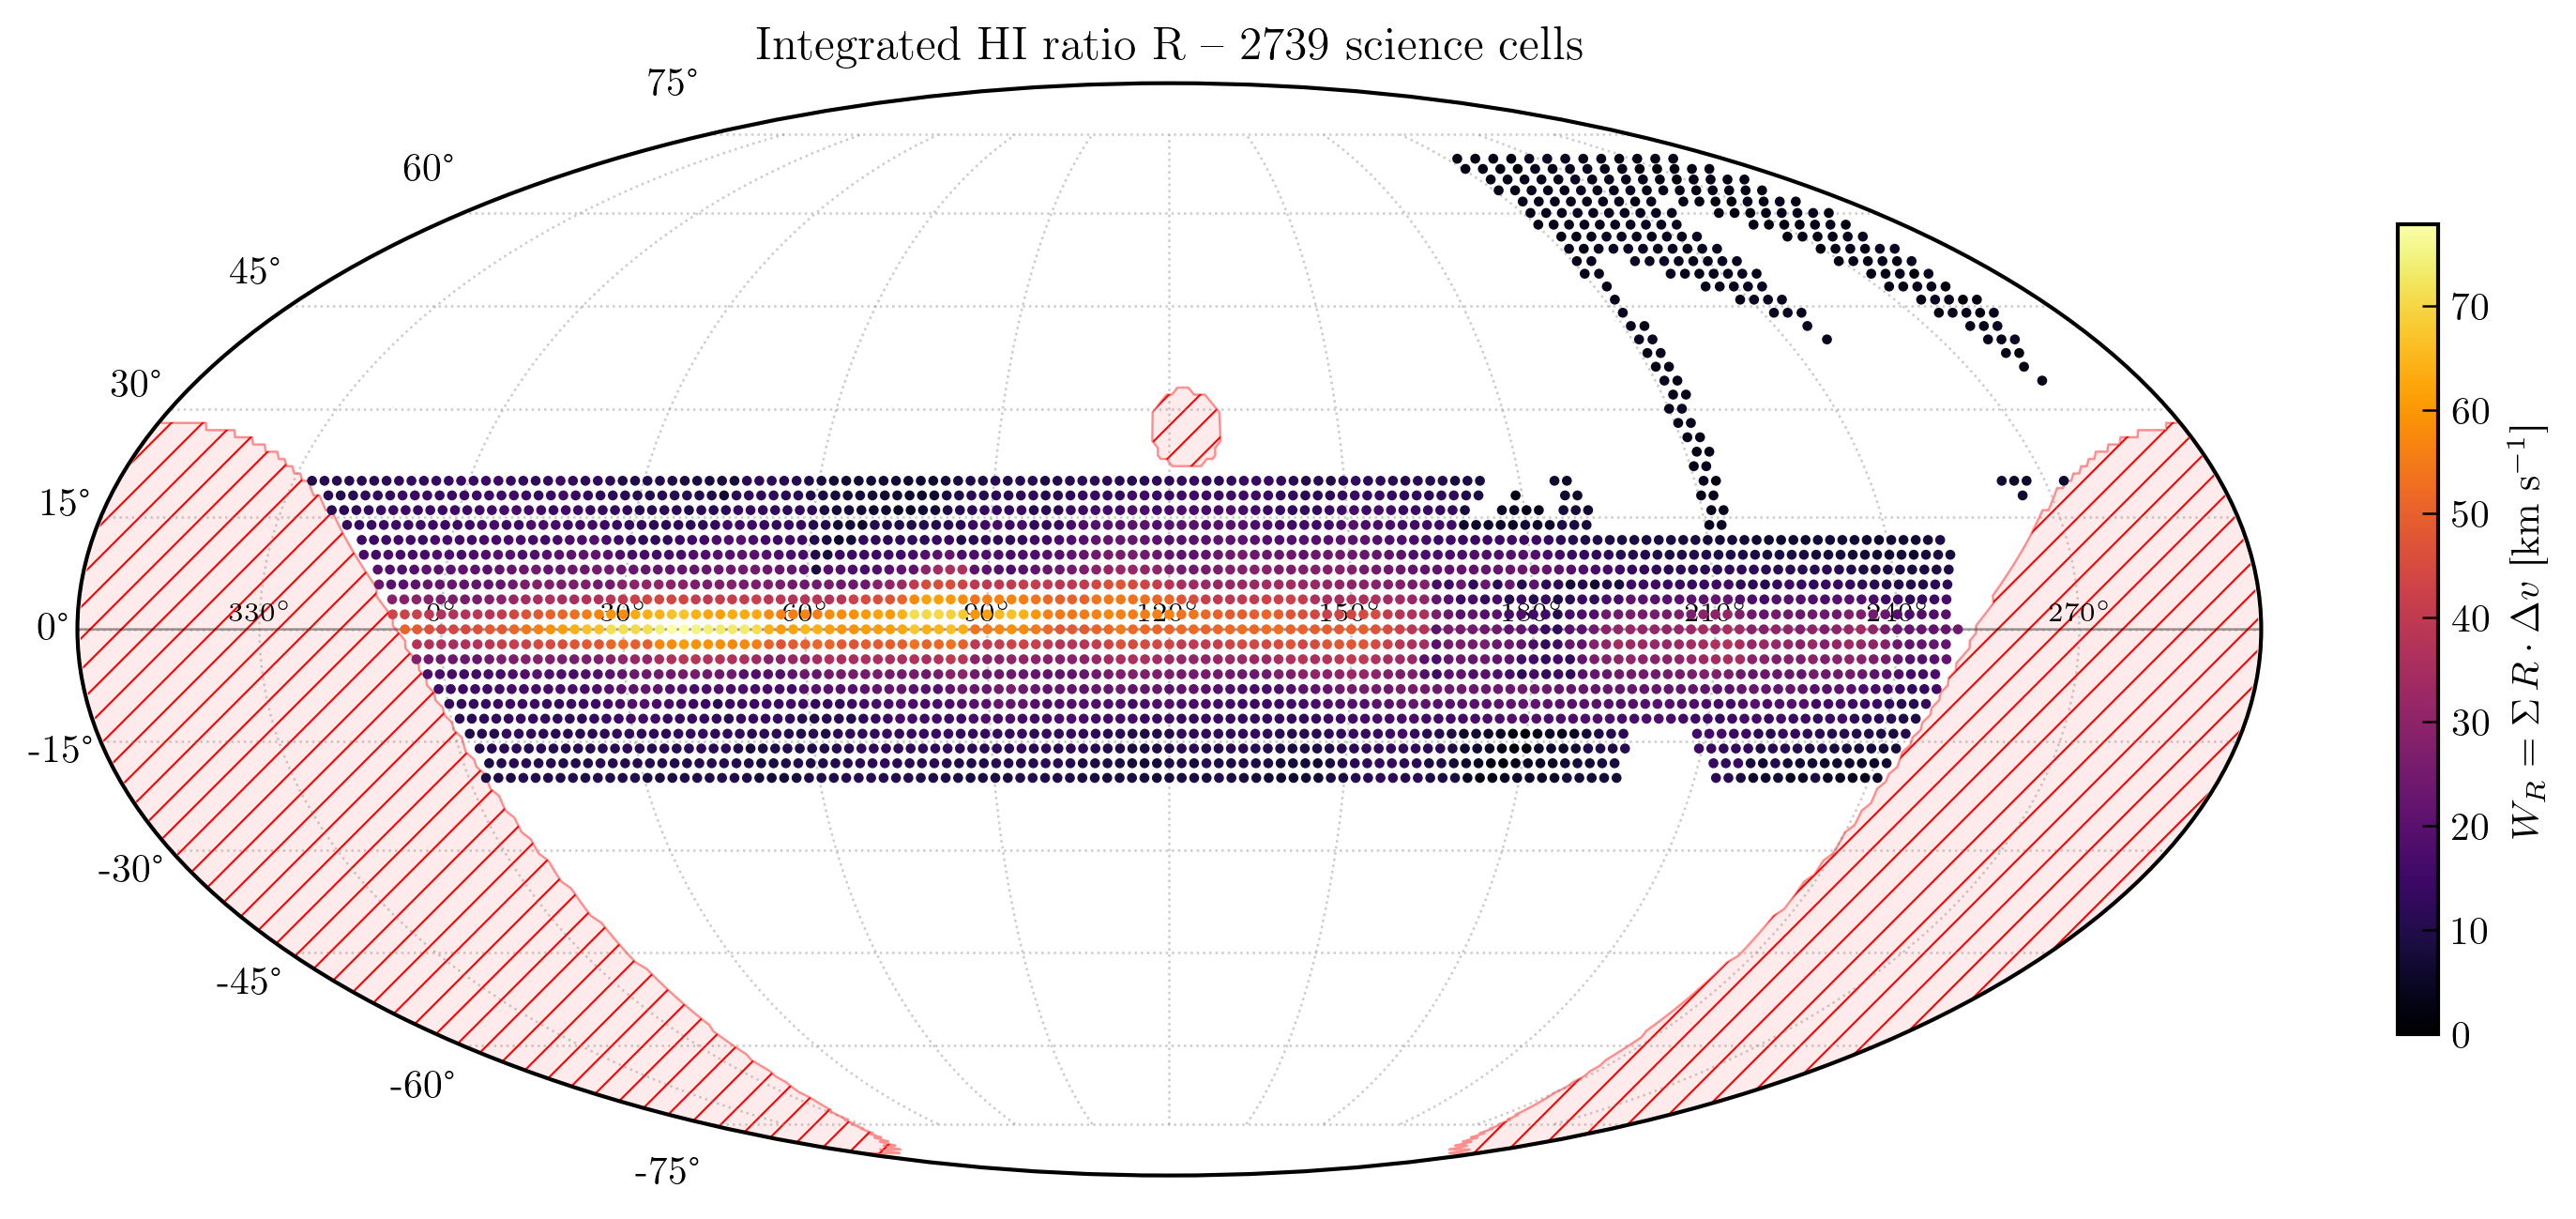

In [6]:
# Plot-stage Stokes I: sum the per-pol R means into a single 'R' key.
for entry in cell_combined.values():
    entry['R'] = entry['R_pol0'] + entry['R_pol1']

arrs = assemble_W_R_arrays(
    cell_combined, {}, set(), dv_kms, spectrum_key='R',
)
gl_arr, gb_arr, W_R, valid_R = arrs['gl'], arrs['gb'], arrs['W_R'], arrs['valid']

fig, ax = plot_survey_mollweide(
    gl_arr[valid_R], gb_arr[valid_R], W_R[valid_R],
    center_l=MOLL_CENTER_L,
    cbar_label=r'$W_R = \Sigma\, R \cdot \Delta v$ [km s$^{-1}$]',
    cmap='inferno',
    marker_size=(SS_FINE + SS_MICRO) / 2,
    title=f'Integrated HI ratio R -- {arrs["n_sci"]} science cells',
)
plt.show()

## 6. Beam-weighted Mollweide map of integrated R

Beam-weighted resampling of `W_R(l, b)` onto a fine pixel grid. Each
pixel is a Gaussian-beam-weighted average over pointings whose 3.4 deg
HPBW partially overlaps it (cutoff at 2 * HPBW). Pixels with negligible
total weight are masked.

Units are km/s -- no temperature calibration applied.

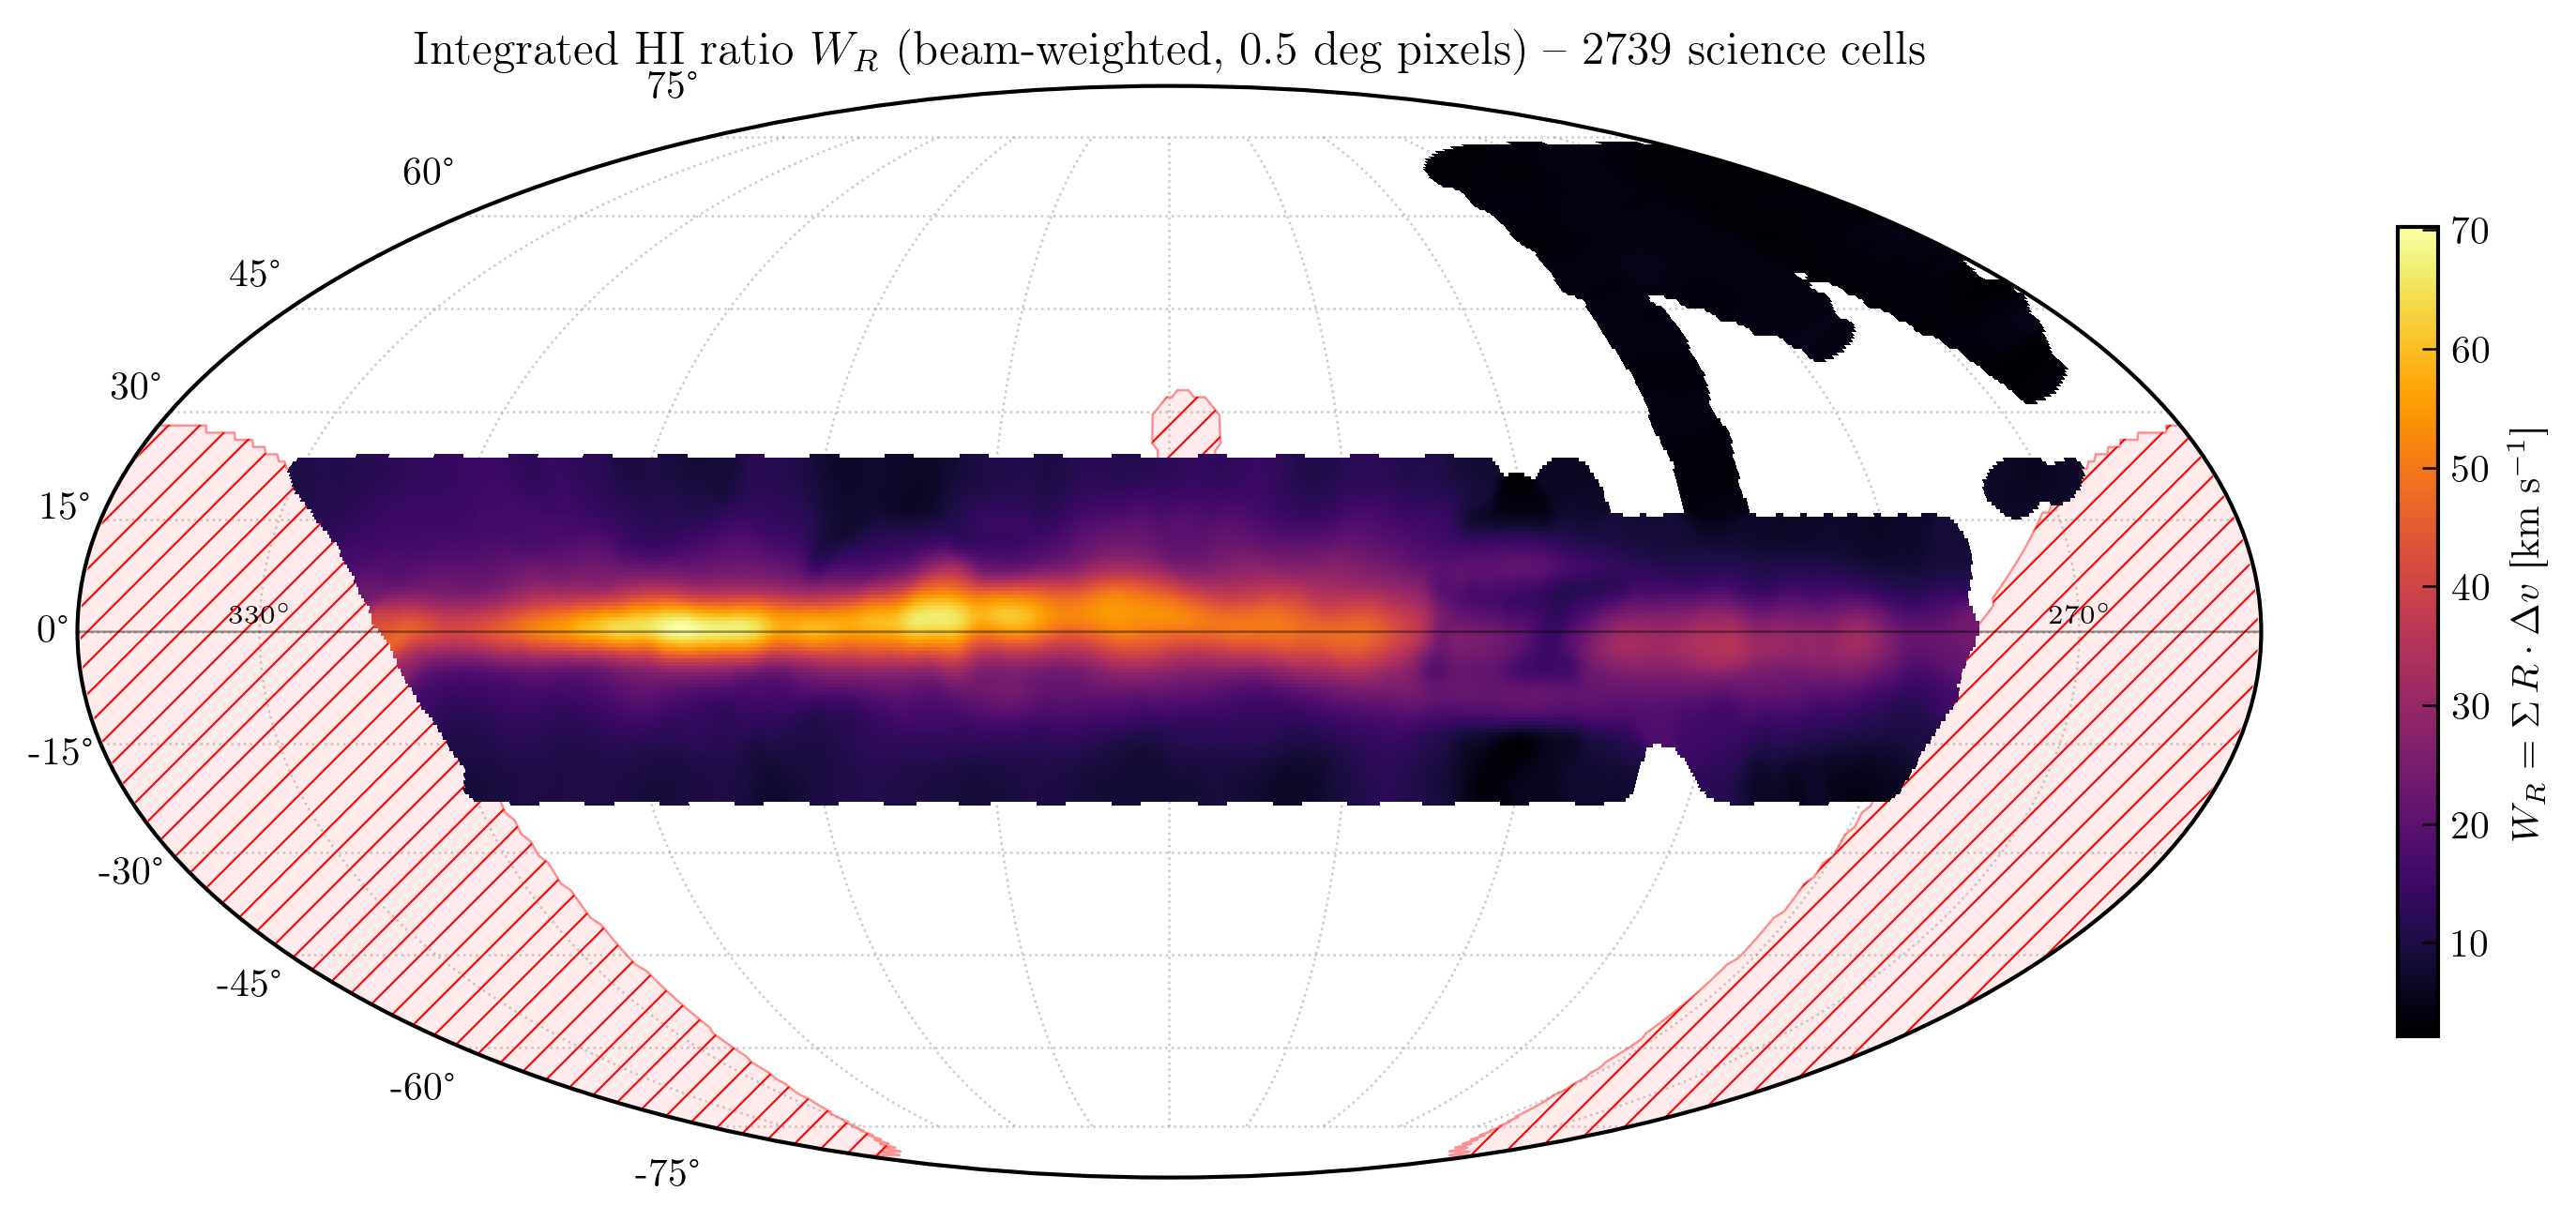

In [7]:
PIXEL_DEG = 0.5      # Mollweide pixel size (deg); finer than HPBW for smooth fill
CUTOFF_HPBW = 2.0    # include pointings within this many HPBW of each pixel center

fig, ax = plot_survey_mollweide_gridded(
    gl_arr[valid_R], gb_arr[valid_R], W_R[valid_R],
    center_l=MOLL_CENTER_L,
    cbar_label=r'$W_R = \Sigma\, R \cdot \Delta v$ [km s$^{-1}$]',
    cmap='inferno',
    hpbw_deg=HPBW_DEG,
    pixel_deg=PIXEL_DEG,
    cutoff_hpbw=CUTOFF_HPBW,
    title=(f'Integrated HI ratio $W_R$ (beam-weighted, {PIXEL_DEG} deg pixels) -- '
           f'{arrs["n_sci"]} science cells'),
)
plt.show()

## 6b. Beam-weighted l-v strip at b ~ 0

Resample (l, b ~ 0) cells onto a fine longitude grid using a Gaussian
beam kernel (sigma = HPBW / 2.355) over all cells with `|b| <= B_MAX_DEG`.
Each (l, v) pixel is `sum(w_i R_i(v)) / sum(w_i)` over contributing
cells, with weights cut off at `CUTOFF_HPBW * HPBW` and pixels with
total weight below `MIN_WEIGHT` masked. Pixels with no cell within
`KEEP_NEAR_HPBW * HPBW` are also masked, which automatically blanks the
never-observable wedge without explicit segment bookkeeping.

The image is in the dimensionless frequency-switched ratio R(v_LSR) (no
T-calibration applied at this stage).

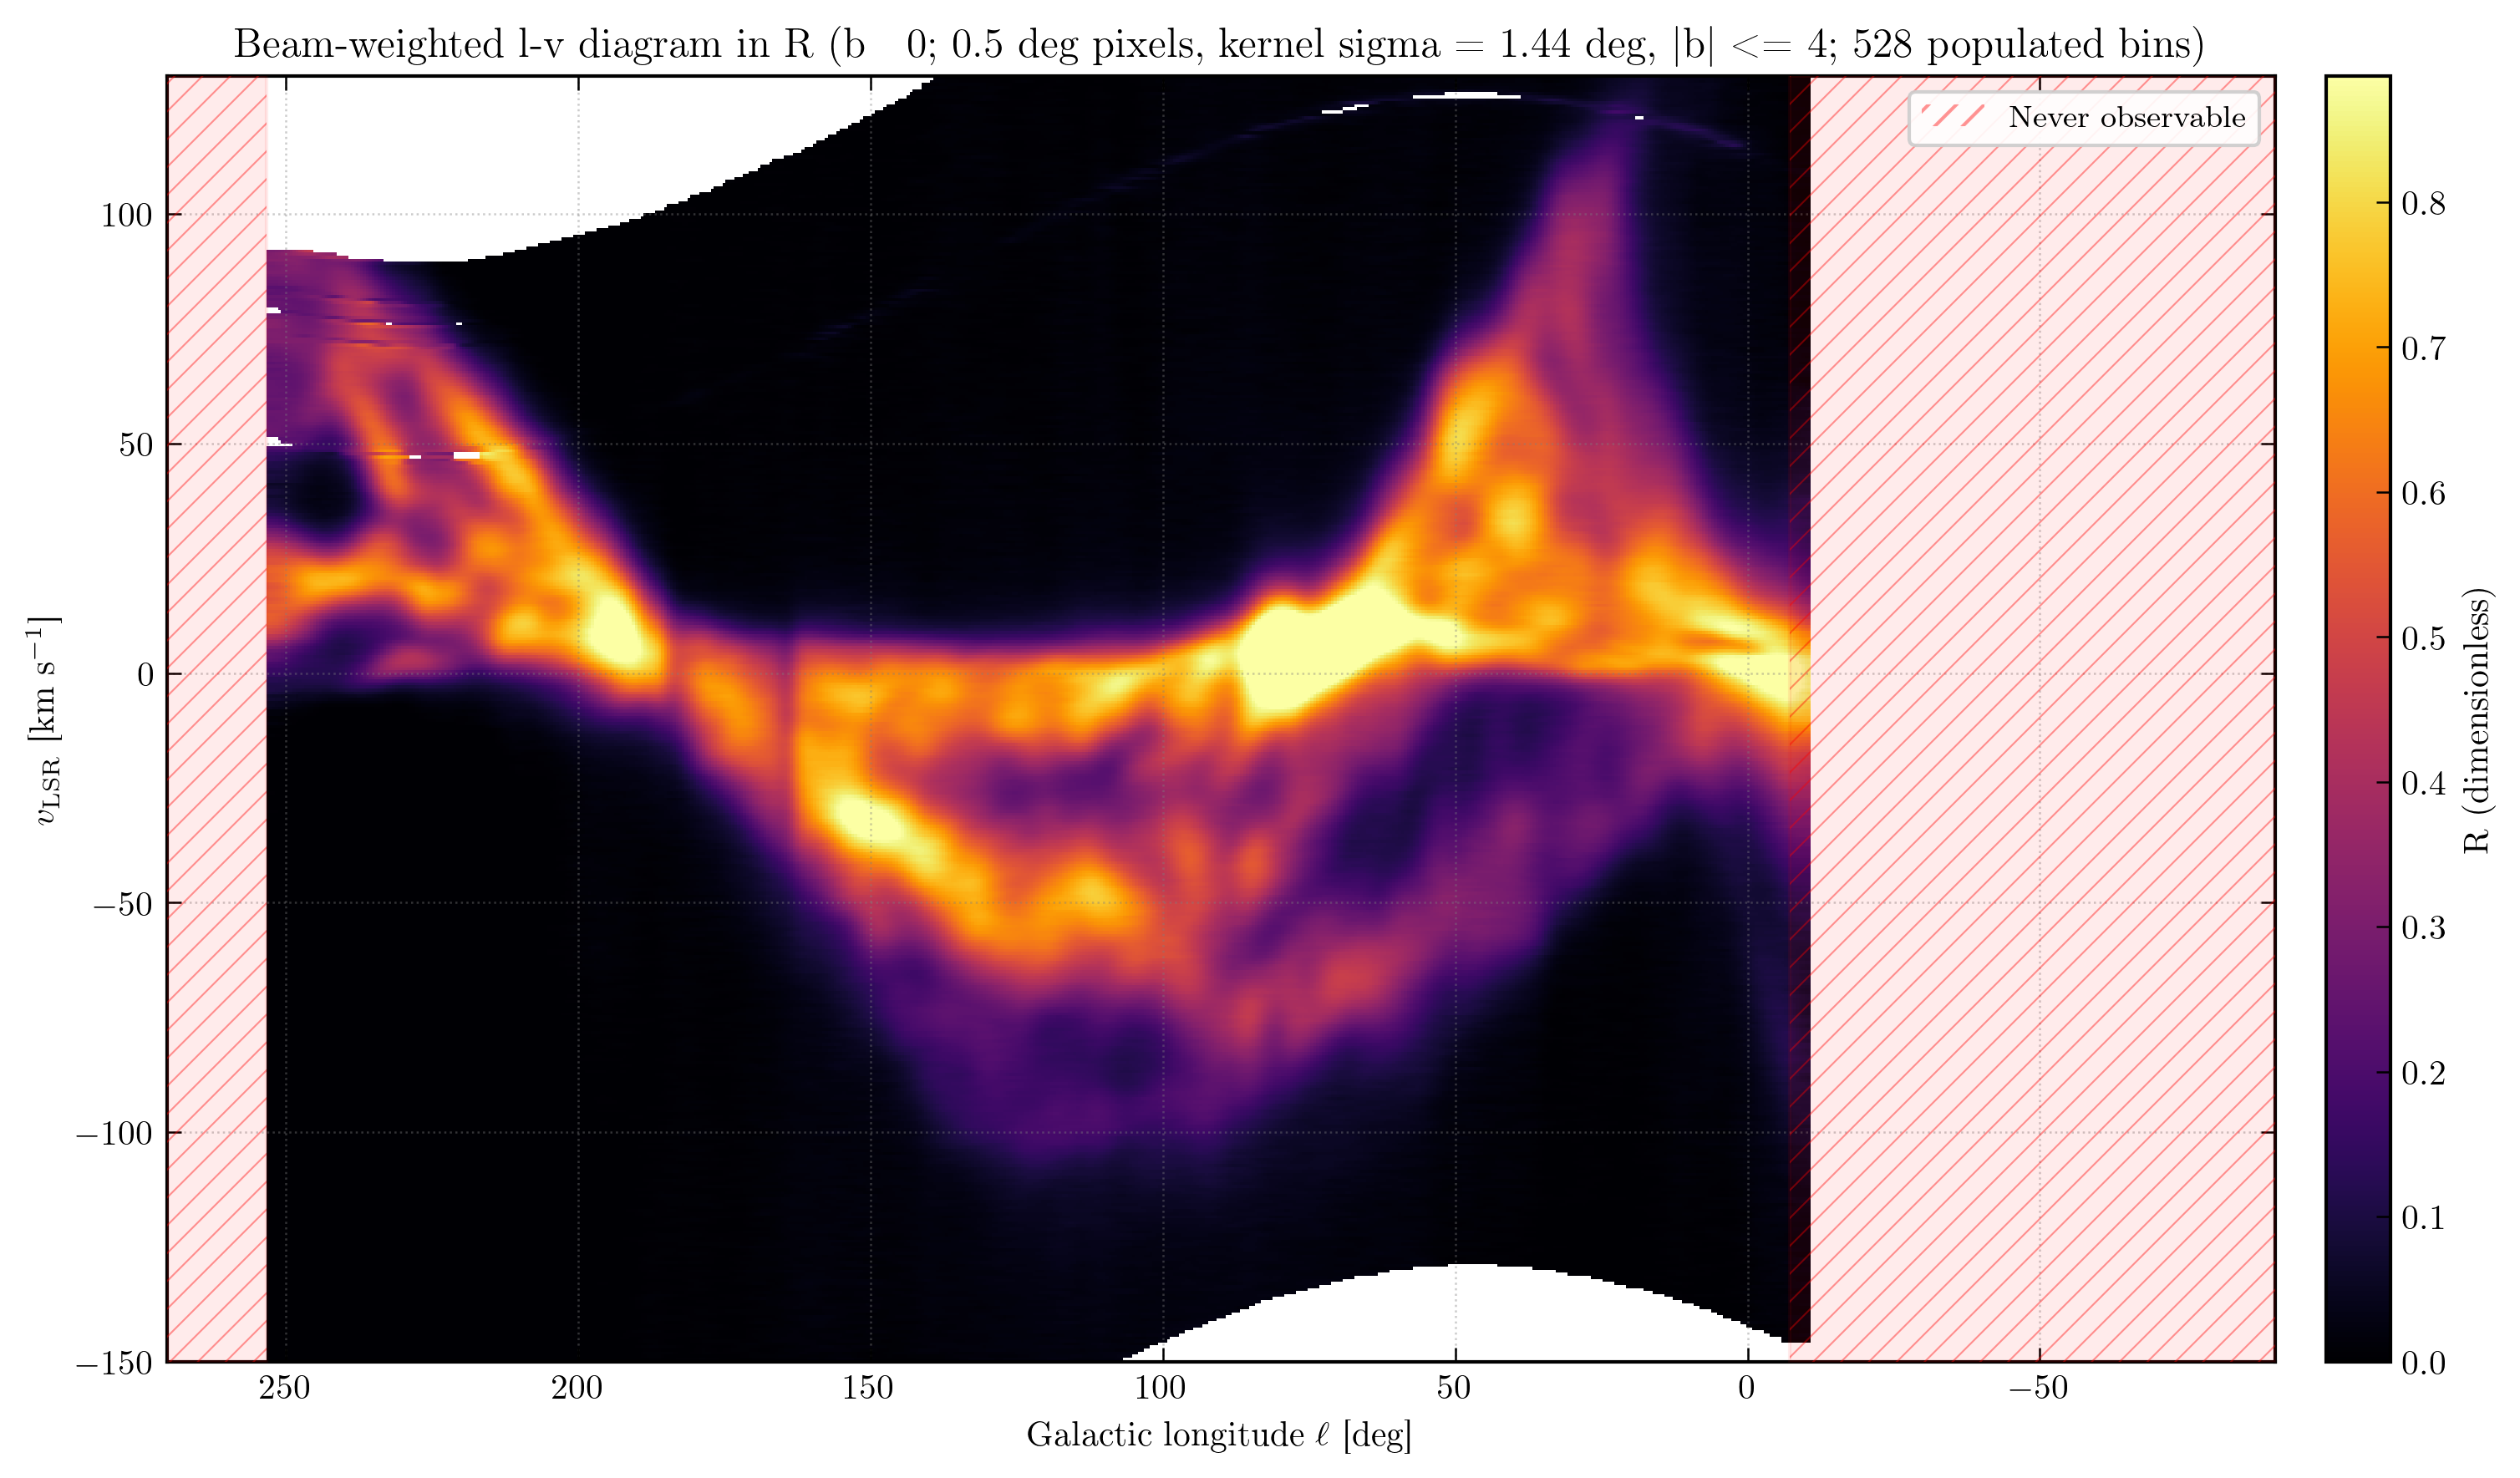

In [8]:
from utils import compute_lv_strip
from plotters import plot_lv_strip

LV_DL_FINE = 0.5
B_MAX_DEG = 4.0

strip = compute_lv_strip(
    cell_combined, cells_insufficient_pairs,
    b_max_deg=B_MAX_DEG,
    dl_fine_deg=LV_DL_FINE,
    hpbw_deg=HPBW_DEG,
    cutoff_hpbw=CUTOFF_HPBW,  # share Section 6's value (2.0)
    spectrum_key='R',
)

fig, ax = plot_lv_strip(
    strip['l_fine'], v_lsr_overlap, strip['lv_image'],
    title=(f"Beam-weighted l-v diagram in R (b ~ 0; "
           f"{LV_DL_FINE} deg pixels, kernel sigma = {strip['sigma_deg']:.2f} deg, "
           f"|b| <= {B_MAX_DEG:.0f}; {strip['n_populated']} populated bins)"),
    cbar_label='R (dimensionless)',
)
plt.show()

## 7. Per-cell calibration scalars (band-averaged P_on, P_off)

Cache the per-(session, cell) noise-on / noise-off band-averaged powers
needed for temperature calibration so `main_scan_qa.ipynb` can apply
`Tcal_pol(t)` from `artifacts/tcal_drift_state.pkl` without re-touching
the raw dumps.

Pols are kept separate. For each `(session, gl, gb, lo_mhz)` and each
pol, band-average `corr00` (pol 0) and `corr11` (pol 1) over the LO
overlap (DC excluded) for noise-on (`cal_*`) and noise-off (`obs_*`)
dumps that survived `flag_outlier_dumps`. Output is a tiny scalar table
keyed per pol; QA then computes per-pol `T_sys_pol = Tcal_pol(t) * P_off_pol / (P_on_pol - P_off_pol)`
and per-pol `T_B_pol = R_pol * T_sys_pol`, finally summing the two pols
at the plot stage.

In [9]:
from utils import compute_cell_scalars, count_fully_calibratable

INT_MASK = overlap_mask.copy()
INT_MASK[NFFT // 2] = False  # exclude DC bin

cell_scalars = compute_cell_scalars(
    records, int_mask=INT_MASK, lo_freqs=(F1_MHZ, F2_MHZ),
)
n_full = count_fully_calibratable(cell_scalars, lo_freqs=(F1_MHZ, F2_MHZ))
print(f'Per-(session, cell) calibration scalars: {len(cell_scalars)} entries')
print(f'  {n_full} have on/off for both LOs and both pols (fully calibratable)')


Per-(session, cell) calibration scalars: 2797 entries
  2797 have on/off for both LOs and both pols (fully calibratable)


## 7b. Edge-clipped recheck manifest

Some cells have HI line emission whose wings reach the edge of the
current LO pair's frequency-switched usable bandwidth -- the line is
clipped at the boundary of `v_lsr_overlap`. Flag those cells and write a
JSON manifest of repointings at a shifted LO pair so the missing wing
gets covered.

LO-pair geometry (`Delta_LO = |F2 - F1|`):

- **Lower pair `(LO0, LO1) = (F1 - Delta_LO, F1)`** -- new overlap shifts
  to lower frequencies, covering more positive v_LSR. Use when the line
  is hot at the most-positive end of `v_lsr_overlap`.
- **Higher pair `(LO2, LO3) = (F2, F2 + Delta_LO)`** -- new overlap
  shifts to higher frequencies, covering more negative v_LSR. Use when
  hot at the most-negative end.

The manifest is consumed by `scripts/main/edges.py` (single-shot
collection driver). Cells are sorted by `|b|` ascending, then by `gl`.

In [10]:
from utils import write_edge_recheck_manifest

# --- Edge-clipped detection thresholds ---
EDGE_KMS = 15.0       # check outer 15 km/s at each end of v_lsr_overlap
EDGE_SIGMA = 5.0      # MAD-sigma threshold for edge emission

# --- Output manifest (consumed by scripts/main/edges.py) ---
RECHECK_PATH = Path('artifacts/edge_clipped_recheck.json')

manifest = write_edge_recheck_manifest(
    cell_combined,
    v_lsr_overlap=v_lsr_overlap,
    edge_kms=EDGE_KMS,
    sigma_thresh=EDGE_SIGMA,
    excluded=cells_insufficient_pairs,
    current_pair_mhz=(F1_MHZ, F2_MHZ),
    path=RECHECK_PATH,
    spectrum_key='R',
)

n_lower  = sum(1 for c in manifest['cells'] if c['suggested_pair'] == 'lower')
n_higher = sum(1 for c in manifest['cells'] if c['suggested_pair'] == 'higher')
print(f'Edge-clipped detection (edge_kms={EDGE_KMS}, sigma>{EDGE_SIGMA}): '
      f'{len(manifest["cells"])} cells flagged '
      f'({n_lower} lower pair, {n_higher} higher pair)')
print(f'  Lower  pair (LO0, LO1) = {tuple(manifest["lower_pair_mhz"])} MHz')
print(f'  Higher pair (LO2, LO3) = {tuple(manifest["higher_pair_mhz"])} MHz')
print(f'Wrote {RECHECK_PATH}')


Edge-clipped detection (edge_kms=15.0, sigma>5.0): 39 cells flagged (39 lower pair, 0 higher pair)
  Lower  pair (LO0, LO1) = (1418.58, 1419.86) MHz
  Higher pair (LO2, LO3) = (1421.14, 1422.42) MHz
Wrote artifacts/edge_clipped_recheck.json


In [11]:
# Export state for main_scan_qa.ipynb /
# main_scan_load_diagnostics.ipynb.  cell_combined entries carry the
# per-pol dimensionless ratios R_pol0(v_LSR) and R_pol1(v_LSR); plot
# stages sum them.  cell_scalars carries per-pol band-averaged P_on /
# P_off scalars (P_on_pol{0,1}_{lo}, P_off_pol{0,1}_{lo}) so QA can
# apply Tcal_pol(t) to each pol independently:
#   T_sys_pol = Tcal_pol(t) * P_off_pol / (P_on_pol - P_off_pol)
#   T_B_pol   = R_pol * T_sys_pol
import pickle

state = {
    'cell_combined': cell_combined,
    'viable_pairs_per_cell': viable_pairs_per_cell,
    'cells_insufficient_pairs': cells_insufficient_pairs,
    'v_lsr_overlap': v_lsr_overlap,
    'dv_kms': dv_kms,
    'overlap_mask': overlap_mask,
    'int_mask': INT_MASK,
    'sessions': sessions,
    'lo_pair_mhz': (F1_MHZ, F2_MHZ),
    'cell_scalars': cell_scalars,
}
with open(STATE_PATH, 'wb') as f:
    pickle.dump(state, f)
print(f'Wrote {STATE_PATH} ({STATE_PATH.stat().st_size/1e6:.2f} MB) -- '
      f'{len(cell_combined)} science cells, '
      f'{len(cell_scalars)} cell-scalar entries')


Wrote artifacts/scan_load_state.pkl (112.87 MB) -- 2739 science cells, 2797 cell-scalar entries
